In [ ]:
import os
import re
import json
import time
import numpy as np
from langchain.chains.question_answering import load_qa_chain 
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chat_models import AzureChatOpenAI
from langchain.embeddings.openai import OpenAIEmbeddings 
from langchain.vectorstores.azuresearch import AzureSearch
from langchain.embeddings import OpenAIEmbeddings
from langchain.document_loaders import PDFPlumberLoader
from azure.search.documents import SearchClient  
from azure.core.credentials import AzureKeyCredential

import warnings
warnings.filterwarnings("ignore")

azure_model = AzureChatOpenAI(openai_api_key="",
                  openai_api_version="",
                  openai_api_base="",
                  deployment_name='',
                  model_name="gpt-4-32k", 
                  temperature=0,
                  max_tokens=2000
                 )

In [2]:
# from typing import List

# class Document:
#     def __init__(self, page_content: str):
#         self.page_content = page_content

# documents_with_state: List = compression_retriever.get_relevant_documents(query)

# documents: List[Document] = [Document(doc.page_content) for doc in documents_with_state]

# text=[]
# for document in documents:
#     text.append(document.page_content)

# text=str(text)

In [3]:
# import PyPDF2

# def pdf_to_text(pdf_file, text_file):
#     pdf_file_obj = open(pdf_file, 'rb')
#     pdf_reader = PyPDF2.PdfReader(pdf_file_obj)
#     num_pages = len(pdf_reader.pages)  # Get the number of pages
#     text = ''
#     for page in pdf_reader.pages:  # Iterate over the pages
#         text += page.extract_text()
#     pdf_file_obj.close()
#     with open(text_file, 'w',encoding='utf-8') as f:
#         f.write(text)

# pdf_file = r'C:\DB\graphrag\PDF files\ulvr-anonymized.pdf'
# text_file = r'C:\DB\graphrag\output.txt'
# pdf_to_text(pdf_file, text_file)

In [4]:
t = []
with open('output.txt', 'r',encoding = 'UTF-8') as file:
    content = file.read()
    t.append(content)

t=str(t)

In [5]:
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_core.documents import Document

llm_transformer = LLMGraphTransformer(llm=azure_model,allowed_nodes=['EBITDA','Cash Flow','EBIT','change in net debt', 'FCF', 'free cash flow'],allowed_relationships=['Has_FinancialMetric'])
documents = [Document(page_content=t)]
  
graph_documents = llm_transformer.convert_to_graph_documents(documents)

print(f"Nodes:{graph_documents[0].nodes}")
print(f"Relationships:{graph_documents[0].relationships}")


Nodes:[Node(id='35', type='change in net debt'), Node(id='11,984', type='EBITDA'), Node(id='10,374', type='EBIT'), Node(id='11,510', type='EBITDA'), Node(id='8,608', type='Cash Flow'), Node(id='8,530', type='Cash Flow'), Node(id='9,123', type='Cash Flow'), Node(id='13,196', type='EBITDA'), Node(id='FCF', type='FCF'), Node(id='6,600', type='FCF'), Node(id='Cash Flow', type='Cash Flow'), Node(id='-637', type='change in net debt'), Node(id='7,060', type='FCF'), Node(id='9,143', type='Cash Flow'), Node(id='EBIT', type='EBIT'), Node(id='11,520', type='EBIT'), Node(id='10,982', type='EBIT'), Node(id='change in net debt', type='change in net debt'), Node(id='9,931', type='EBIT'), Node(id='-713', type='change in net debt'), Node(id='EBITDA', type='EBITDA'), Node(id='-455', type='change in net debt'), Node(id='6,592', type='FCF'), Node(id='7,440', type='FCF'), Node(id='12,625', type='EBITDA')]
Relationships:[Relationship(source=Node(id='EBITDA', type='EBITDA'), target=Node(id='11,510', type='EB

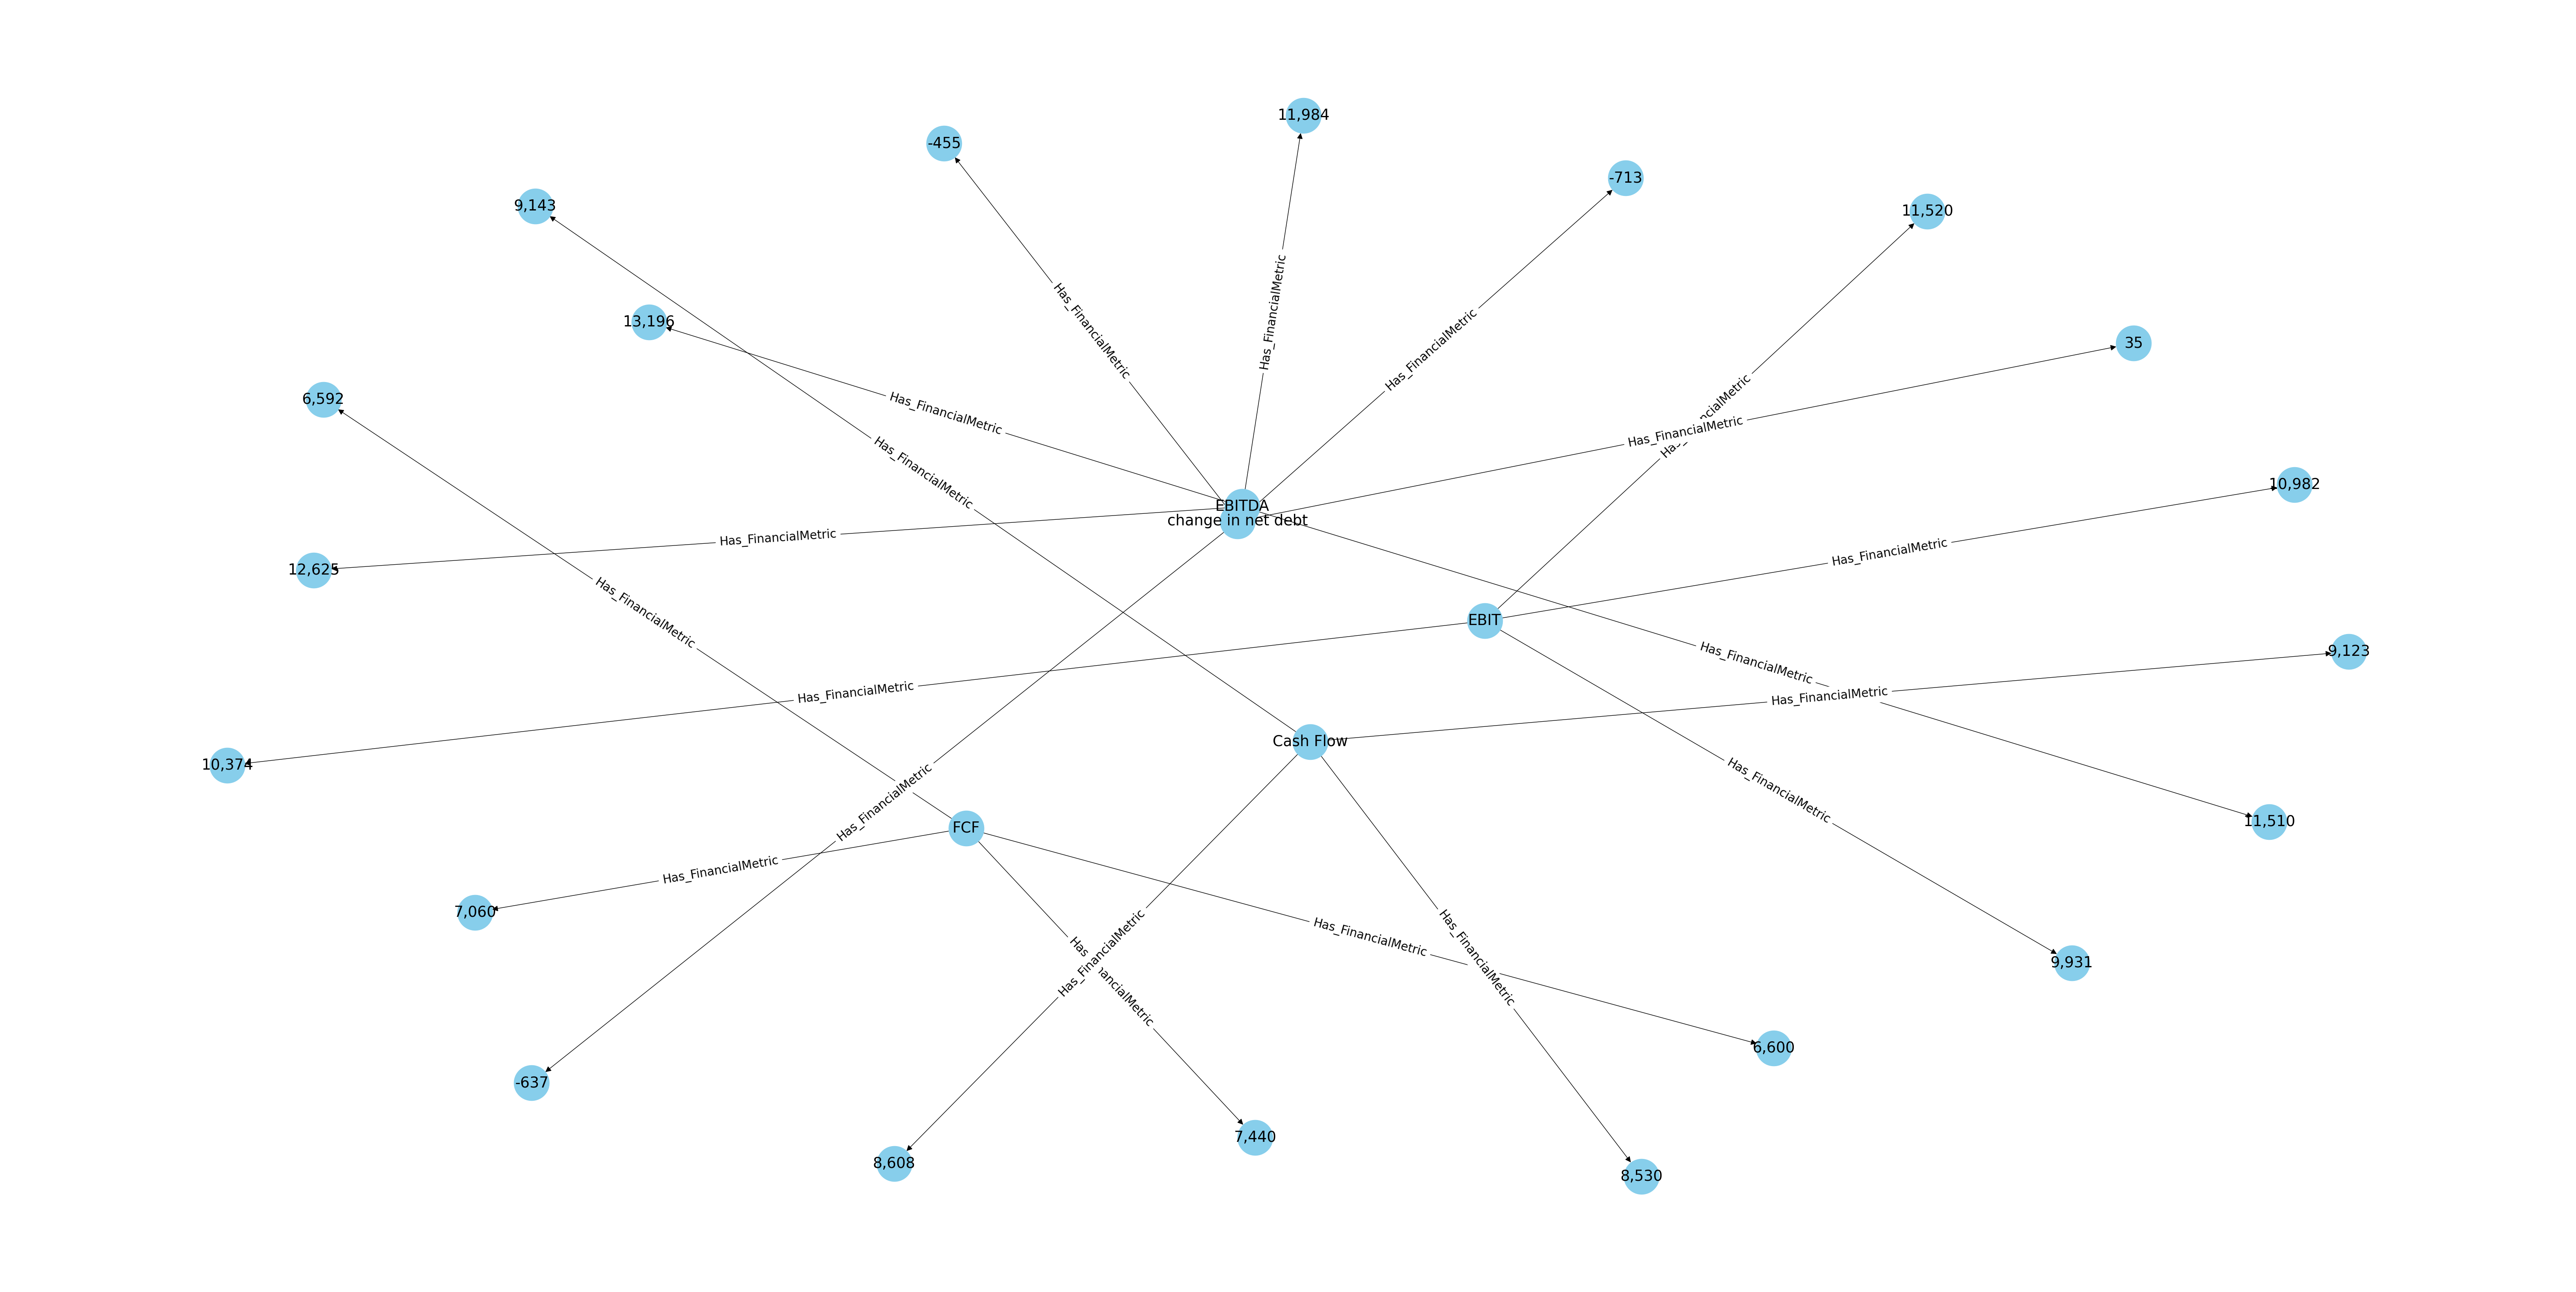

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Create a dictionary to map Node objects to node IDs
node_ids = {}
for i, node in enumerate(graph_documents[0].nodes):
    node_id = str(i)
    node_ids[node_id] = node
    G.add_node(node_id, label=node.id)

# Add edges to the graph
for relationship in graph_documents[0].relationships:
    start_node_id = [node_id for node_id, node in node_ids.items() if node == relationship.source][0]
    end_node_id = [node_id for node_id, node in node_ids.items() if node == relationship.target][0]
    G.add_edge(start_node_id, end_node_id, label=relationship.type)

plt.figure(figsize=(60, 30))

# Draw the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=False, node_color='skyblue', node_size=3500, edge_color='black', linewidths=1, font_size=25, arrowsize=20)

# Draw node labels
node_labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels=node_labels,font_size=25)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,font_size=20)

plt.show()